<a href="https://colab.research.google.com/github/MaryamAmjad2/PyTorch/blob/main/03_CV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#0. CV Liabraries

In [1]:
# !pip install torchmetrics

In [2]:
import torch
from torch import nn
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split

# CV Libs
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
# from torchmetrics import Accuracy


import matplotlib.pyplot as plt




# 1. Getting DataSet

Using FashionMNIST from torchvision.Dataset

In [3]:
train_data=datasets.FashionMNIST(
    root='data', # where to download data to
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None

)

test_data=datasets.FashionMNIST(
    root='data',
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None

)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.78MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.3MB/s]


In [4]:
len(train_data), len(test_data)

(60000, 10000)

In [5]:
class_to_idx=train_data.class_to_idx
class_to_idx   #  Gives a dictionary of data

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [6]:
class_names = train_data.classes

In [7]:
train_data.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

In [8]:
print(train_data.classes)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


##1.2 Visaulize

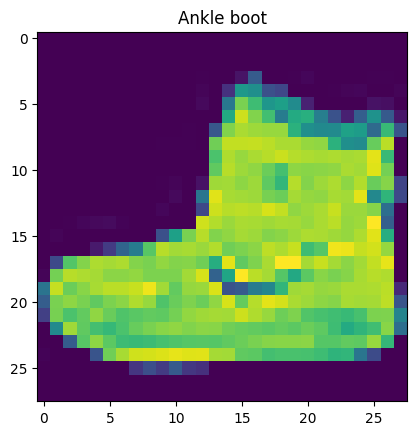

In [9]:
image,label=train_data[0]
image.shape

# Gets Eror Cz Color channel is infront and matplotlib requires it in the end
# plt.imshow(image)
plt.title(train_data.classes[label])
plt.imshow(image.squeeze())  #Removing the color channel for now

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

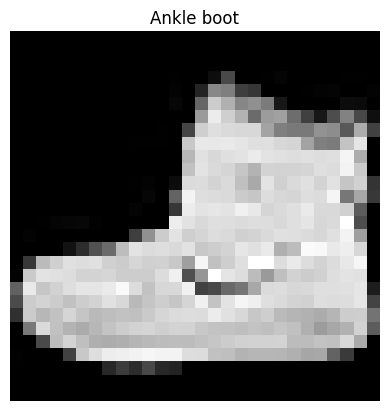

In [10]:
plt.imshow(image.squeeze(), cmap='gray')
plt.title(train_data.classes[label])
plt.axis(False)

Plot More Images

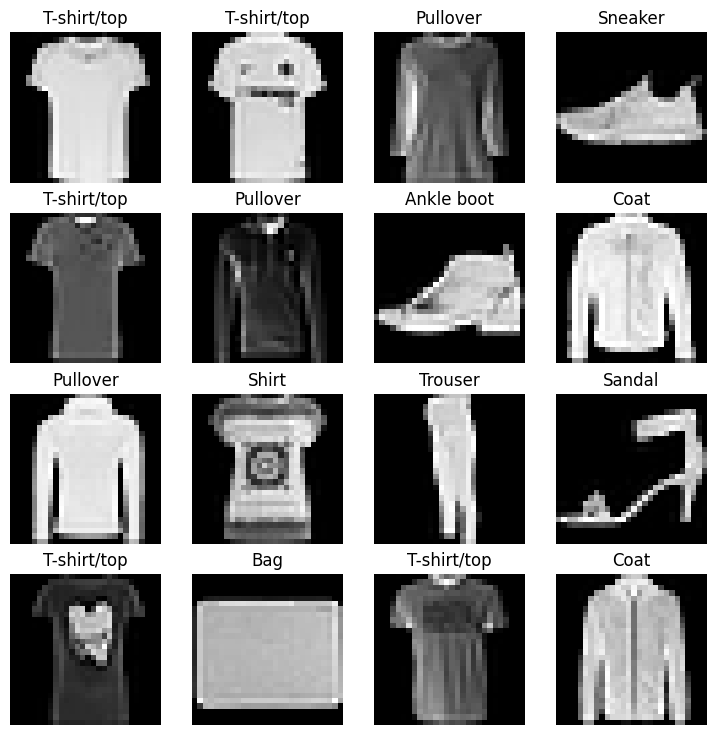

In [11]:
# torch.manual_seed(42)
fig=plt.figure(figsize=(9,9))
rows,cols=4,4
for i in range( 1,rows* cols+1):
  rand_idx=torch.randint(0,len(train_data),size=[1]).item()
  # print(rand_idx)
  image,label=train_data[rand_idx]
  fig.add_subplot(rows,cols,i)
  plt.imshow(image.squeeze(),cmap='gray')
  plt.title(train_data.classes[label])
  plt.axis(False)


# 2.  Prepare DataLoader

Turns dataset into pyton iteratables.

Turn Data into mini batches

shuffle training data mainly to prevent your model from learning the order of the data instead of the actual patterns.

In [12]:
BATCH_SIZE=32

train_dataloader= DataLoader(dataset=train_data,
                             batch_size=BATCH_SIZE,
                             shuffle=True)

test_dataloader=DataLoader(dataset=test_data,
                     batch_size=BATCH_SIZE,
                     shuffle=False)
train_dataloader,test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7fa02b5ad2b0>,
 <torch.utils.data.dataloader.DataLoader at 0x7fa028a2bd90>)

In [13]:
print(f'Total {len(train_dataloader)} batches')

Total 1875 batches


In [14]:
train_features_batch,train_labels_batch=next(iter(train_dataloader))
train_features_batch.shape

torch.Size([32, 1, 28, 28])

Image Shape istorch.Size([1, 28, 28])
Label Shape istorch.Size([])


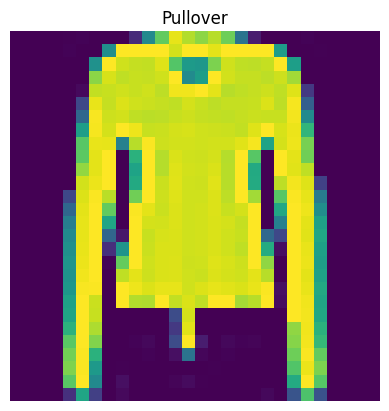

In [15]:
# Show sample

# torch.manual_seed(42)
random_idx=torch.randint(0,len(train_features_batch),
                          size=[1]).item()

img,label=train_features_batch[random_idx],train_labels_batch[random_idx]
plt.imshow(img.squeeze())
plt.title(train_data.classes[label])
plt.axis(False)
print(f'Image Shape is{img.shape}')
print(f'Label Shape is{label.shape}')

# 3. Model

In [16]:
# Creating a Flat Layer
flatten_model=nn.Flatten()

# Get a Single Sample
x= train_features_batch[0]
print(x.shape)
output=flatten_model(x)
print(output.shape)

torch.Size([1, 28, 28])
torch.Size([1, 784])


In [17]:
class FashionMNISTModelV0(nn.Module):
  def __init__(self,input_shape:int,
               hidden_units:int,
               output_shape:int
               ):
    super().__init__()
    self.layer_stack=nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape,out_features=hidden_units,),
        nn.Linear(in_features=hidden_units,out_features=output_shape,),
        )

  def forward(self,x:torch):
    return self.layer_stack(x)



In [18]:
torch.manual_seed(42)

model_0=FashionMNISTModelV0(784,10,len(class_names))

In [19]:
model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [20]:
dummy_x=torch.rand([1,1,28,28])
model_0(dummy_x)

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], grad_fn=<AddmmBackward0>)

# 3.1 Loss And Optimizer

In [21]:
loss_fn=nn.CrossEntropyLoss()

In [22]:
optimizer=torch.optim.SGD(params=model_0.parameters(),lr=0.1)

In [23]:
import requests
from pathlib import Path

# Download Helper Function
if Path('helper_function.py').is_file():
  print("Yes")
else:
  print("Downloading ")
  request=requests.get('https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py')
  with open('helper_function.py','wb') as f:
    f.write(request.content)

# Function to Time Experiments

In [24]:
from helper_function import accuracy_fn
from timeit import default_timer as timer

def print_train_time(start:float,end:float,device:torch.device=None):
  total_time=end-start
  print(f"Train Time on {device} :{total_time} seconds")
  return total_time



In [25]:
start_time=timer()
for i in range (10):
  print(i)
end_time=timer()
print_train_time(start_time,end_time)

0
1
2
3
4
5
6
7
8
9
Train Time on None :0.00020531300003767683 seconds


0.00020531300003767683

# 4. Train and Test

Optim update per batch not per image

In [26]:
len(train_dataloader)

1875

In [27]:
# batch * len(X)/len(train_dataloader.dataset)

In [28]:
from tqdm.auto import tqdm

# Start Timer
torch.manual_seed(42)
train_time_start_on_cpu = timer()

epochs = 3

for epoch in tqdm(range(epochs)):
    print(f'Epoch: {epoch}')

    # Training
    train_loss = 0
    # Loop to loop through batches
    for batch, (X, y) in enumerate(train_dataloader):
        model_0.train()
        y_pred = model_0(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 400 == 0:
            print(f'Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples')

    # Average Train Loss Per Batch
    train_loss /= len(train_dataloader)

    # Testing
    test_loss = 0
    test_acc = 0
    model_0.eval()
    with torch.inference_mode():
        for X_test, y_test in test_dataloader:
            y_test_pred = model_0(X_test)

            # Cal Loss
            test_loss += loss_fn(y_test_pred, y_test)


            test_acc += accuracy_fn(y_test, y_test_pred.argmax(dim=1))

        # Calculate Test Loss Average Per Batch
        test_loss /= len(test_dataloader)
        # Calculate Test Acc Average Per Batch
        test_acc /= len(test_dataloader)

    print(f'Train Loss {train_loss:.3f} | Test Loss {test_loss:.3f} | Test Accuracy {test_acc:.4f}')


# Calculate Train Time
train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(
    train_time_start_on_cpu,
    train_time_end_on_cpu,
    device=next(model_0.parameters()).device
)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train Loss 0.590 | Test Loss 0.510 | Test Accuracy 82.0387
Epoch: 1
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train Loss 0.476 | Test Loss 0.480 | Test Accuracy 83.1969
Epoch: 2
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train Loss 0.455 | Test Loss 0.477 | Test Accuracy 83.4265
Train Time on cpu :30.61860066899999 seconds


In [29]:
len(str(next(model_0.parameters())))

482

# 5 Make Predictions and get model Result

In [30]:
device='cuda' if torch.cuda.is_available() else 'cpu'

In [31]:
torch.manual_seed(42)
def eval_model(model:torch.nn.Module, data_loader: torch.utils.data.DataLoader,
              loss_fn:torch.nn.Module,
              accuracy_fn
              ):
  """Return dict contaning the results of model predicting on dataLoader"""

  loss,acc=0,0
  model.eval()
  with torch.inference_mode():
    for X,y in tqdm(data_loader):
      X,y=X.to(device),y.to(device)
      model=model.to(device)
      y_pred=model(X)

      # Acumulate loss and Acc per Batch
      loss+=loss_fn(y_pred,y)
      acc+=accuracy_fn(y,y_pred.argmax(dim=1))

    # Average Loss and Acc Per Batch
    loss/=len(data_loader)
    acc/=len(data_loader)


  return {"model_name":model.__class__.__name__,
          "model_losss":loss.item(),
          "model_acc": acc

          }

# Calculate Model 0 Results on test dataset
model_0_results = eval_model(model_0,test_dataloader,
                           loss_fn,accuracy_fn)
model_0_results



  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV0',
 'model_losss': 0.4766389727592468,
 'model_acc': 83.42651757188499}

# 6. Setup device Agnostic Code

In [32]:
torch.cuda.is_available()

True

In [33]:
device

'cuda'

# 7. Non- Linear Model and Running it on GPU

In [34]:
class FashionMNISTModelV1(nn.Module):
  def __init__(self,input_shape,
               output_shape,
               hidden_units):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape,out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units,out_features=output_shape),

    )
  def forward(self,x):
    return self.layer_stack(x)


In [35]:
torch.manual_seed(42)
model_1 = FashionMNISTModelV1(784,10,10).to(device)

next(model_1.parameters()).device

device(type='cuda', index=0)

## Loss and Optimizer

In [36]:
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(params=model_1.parameters(),lr=0.1)

## Training and Test Loop Function

In [37]:
from helper_function import accuracy_fn
def train_steps(model:torch.nn.Module,
                data_loader:torch.utils.data.DataLoader,
                loss_fn:torch.nn.Module,
                optimizer:torch.nn.Module,
                accuracy_fn,
                device:torch.device=device):


  # Training Steps
  train_loss,train_acc=0,0
  model.train()
  for batch, (X,y) in enumerate(data_loader):

    # Put data on Target Device
    X,y=X.to(device),y.to(device)

    # Forward Pass
    y_pred=model(X)

    #Loss Function
    loss=loss_fn(y_pred,y)
    train_loss+=loss
    train_acc+=accuracy_fn(y,y_pred.argmax(dim=1)) # logits-> Prediction Label

    #Optimizer Zero Grad
    optimizer.zero_grad()

    loss.backward()


    optimizer.step()

  # Print it out
  train_loss/=len(data_loader)
  train_acc/=len(data_loader)
  print(f' Train Loss :{train_loss:.4f}, Train Accuracy {train_acc:.4f}& ')






In [38]:
def test_steps(model:torch.nn.Module,
                data_loader:torch.utils.data.DataLoader,
                loss_fn:torch.nn.Module,
                optimizer:torch.nn.Module,
                accuracy_fn,
                device:torch.device=device):
  test_loss,test_acc=0,0
  model.eval()
  with torch.inference_mode():
    for batch,(X_test,y_test) in enumerate(data_loader):

      # Sending to device
      X_test,y_test=X_test.to(device),y_test.to(device)

      #Forward pass
      y_test_pred=model(X_test)

      #loss And Accuracy
      test_loss+=loss_fn(y_test_pred,y_test)
      test_acc+=accuracy_fn(y_test,y_test_pred.argmax(dim=1))

    # Adjust Metrics and Print out
    test_loss/=len(data_loader)
    test_acc/=len(data_loader)
    print(f'Test loss: {test_loss:.4f}  Test Accuracy {test_acc:.4f}%\n')




In [39]:
torch.manual_seed(42)
start_time=timer()
epochs=3
for epoch in tqdm(range(epochs)):
  print(f'Epoch {epoch} -----')

  train_steps(model_1,train_dataloader,
             loss_fn,optimizer,
             accuracy_fn,
             device=device)

  test_steps(model_1 , test_dataloader,
             loss_fn , optimizer,
             accuracy_fn,
             device=device)
end_time=timer()
total_time_model1=print_train_time(start_time,end_time,device=device)
print(" Total Time Taken ", total_time_model1)


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 0 -----
 Train Loss :0.6461, Train Accuracy 77.1700& 
Test loss: 0.5386  Test Accuracy 80.7608%

Epoch 1 -----
 Train Loss :0.4809, Train Accuracy 82.9433& 
Test loss: 0.4939  Test Accuracy 82.4581%

Epoch 2 -----
 Train Loss :0.4469, Train Accuracy 84.1633& 
Test loss: 0.4575  Test Accuracy 83.9856%

Train Time on cuda :39.26910886500002 seconds
 Total Time Taken  39.26910886500002


In [40]:
total_train_time_model_0

30.61860066899999

# Results

In [41]:
model_0_results=eval_model(model_0,test_dataloader,
                           loss_fn=loss_fn,
                           accuracy_fn=accuracy_fn)
model_0_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV0',
 'model_losss': 0.4766389727592468,
 'model_acc': 83.42651757188499}

In [42]:
model_1_results=eval_model(model_1,test_dataloader,
                           loss_fn=loss_fn,
                           accuracy_fn=accuracy_fn,
                          )
model_1_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV1',
 'model_losss': 0.45746350288391113,
 'model_acc': 83.98562300319489}

# CNN

Using Conv2d cause we have 2D images.

we have Conv1D ,Conv3D

2 conv layers, then pool

In [43]:
class FashionMNISTModelV2(nn.Module):
  def __init__(self,input_shape:int
               ,hidden_unit:int,output_shape:int):
    super().__init__()

  # Feature Extracting Layers

    self.conv_block_1=nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_unit,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_unit,
                  out_channels=hidden_unit,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(
                  kernel_size=2),


    )
    self.conv_block_2=nn.Sequential(
        nn.Conv2d(in_channels=hidden_unit,
                  out_channels=hidden_unit,
                  kernel_size=3,
                  stride=1,
                  padding=1),

        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_unit,
                  out_channels=hidden_unit,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)

    )

  # OutPut / Classifier Layer

    self.classifier=nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_unit*7*7 ,
                  out_features=output_shape)
    )


  def forward(self,x):
    x=self.conv_block_1(x)
    # print("OutPut Shape of Block 1 is",x.shape)
    x=self.conv_block_2(x)
    # print("OutPut Shape of Block 2 is", x.shape)
    x=self.classifier(x)
    # print("OutPut Shape of Classofier is", x.shape)
    return x









In [44]:
torch.manual_seed(42)
model_2=FashionMNISTModelV2(1,10,len(class_names)).to(device)


In [45]:
rand_image_tesnor=torch.randn(size=(1,1,28,28)).to(device)
model_2(rand_image_tesnor)

tensor([[ 0.0366, -0.0940,  0.0686, -0.0485,  0.0068,  0.0290,  0.0132,  0.0084,
         -0.0030, -0.0185]], device='cuda:0', grad_fn=<AddmmBackward0>)

## Loss and Optimizer

In [46]:
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(params=model_2.parameters(),
                          lr=0.1)

from helper_function import accuracy_fn

## Train CNN

In [47]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set Timer
start_time_model_2=timer()

epochs=3
for epoch in range(epochs):
  print(f"Epoch {epoch} _______")
  train_steps(model_2,train_dataloader,
              loss_fn,optimizer,accuracy_fn),
  test_steps(model_2,test_dataloader,loss_fn,optimizer,
             accuracy_fn)


end_timer_model_2=timer()
total_time_model_2=print_train_time(start_time_model_2,end_timer_model_2)



Epoch 0 _______
 Train Loss :0.5978, Train Accuracy 78.2983& 
Test loss: 0.3887  Test Accuracy 85.9026%

Epoch 1 _______
 Train Loss :0.3614, Train Accuracy 87.1067& 
Test loss: 0.3482  Test Accuracy 86.9010%

Epoch 2 _______
 Train Loss :0.3241, Train Accuracy 88.2733& 
Test loss: 0.3193  Test Accuracy 88.6082%

Train Time on None :44.32641743900001 seconds


In [48]:
# Get Model_2 Results

model_2_results=eval_model(model_2,test_dataloader,
                           loss_fn,accuracy_fn)
model_2_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV2',
 'model_losss': 0.31928470730781555,
 'model_acc': 88.6082268370607}

# Compare Model Results

In [49]:
compare_results=pd.DataFrame([model_0_results,
                             model_1_results,
                             model_2_results])
compare_results

,model_name,model_losss,model_acc
0,FashionMNISTModelV0,0.476639,83.426518
1,FashionMNISTModelV1,0.457464,83.985623
2,FashionMNISTModelV2,0.319285,88.608227


In [50]:
# Add Training Time to Comparision
compare_results['Train Time']=[total_train_time_model_0,total_time_model1,total_time_model_2]
compare_results

,model_name,model_losss,model_acc,Train Time
0,FashionMNISTModelV0,0.476639,83.426518,30.618601
1,FashionMNISTModelV1,0.457464,83.985623,39.269109
2,FashionMNISTModelV2,0.319285,88.608227,44.326417


Text(0, 0.5, 'Model')

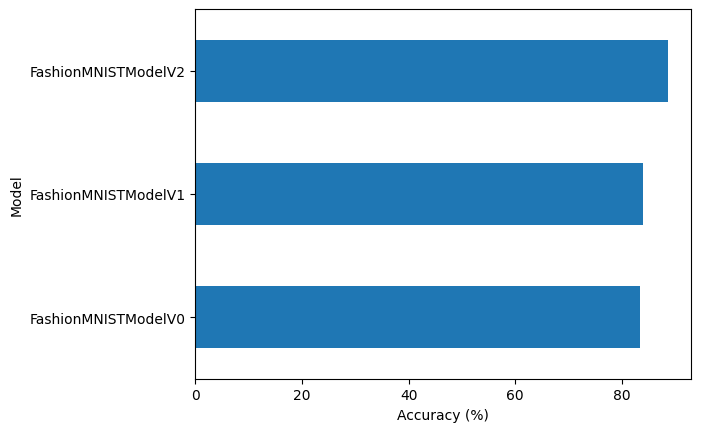

In [51]:
# Visualize Results
compare_results.set_index("model_name")['model_acc'].plot(kind='barh')
plt.xlabel('Accuracy (%)')
plt.ylabel("Model")

# Make Predictions

In [52]:
def make_predictions(model:torch.nn.Module,
                     data:list,
                     device:torch.device=device):
  pred_probs=[]
  model.eval()
  model.to(device)
  with torch.inference_mode():
    for sample in data:

      #Prepare sample data and add a batch dimension
      sample=torch.unsqueeze(sample,dim=0).to(device)

      # Forward Pass (Model Outputs Logits)
      pred_logits=model(sample)

      # Get Prediction Prob
      pred_prob=torch.softmax(pred_logits.squeeze(),dim=0)

      # Get Pred Prob off the GPU
      pred_probs.append(pred_prob.cpu())


    # Stack the Pred Prob to Turn List into a Tensor
    return torch.stack(pred_probs)


Text(0.5, 1.0, 'Ankle boot')

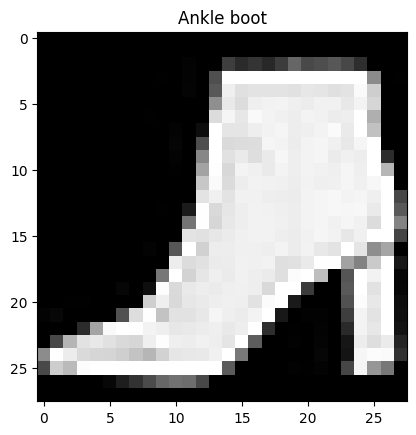

In [53]:
import random
# random.seed(42)
test_sample=[]
test_label=[]

for sample,label in random.sample(list(test_data),k=9):
  test_sample.append(sample)
  test_label.append(label)

test_sample[0].shape
plt.imshow(test_sample[0].squeeze(),cmap='gray')
plt.title(class_names[test_label[0]])

In [54]:
#Make Predictions

pred_probs=make_predictions(model_2,test_sample,device)

# View the first two Prediction Prob
pred_probs[1]

# Convert Prob -> Labels
pred_classes=pred_probs.argmax(dim=1)
pred_classes


tensor([9, 6, 3, 9, 8, 8, 4, 1, 1])

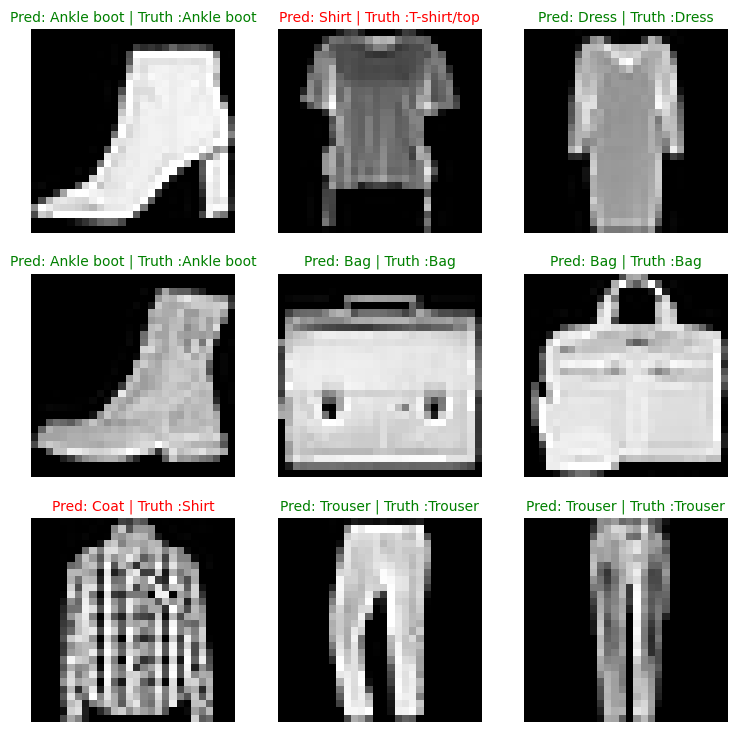

In [55]:
# Plot Predictions
plt.figure(figsize=(9,9))
nrows,ncols=3,3

for i, sample in enumerate(test_sample):
  plt.subplot(nrows,ncols,i+1)

  # Plot the Target Image
  plt.imshow(sample.squeeze(),cmap='gray')

  # Find The prediction
  pred_label=class_names[pred_classes[i]]

  # Get the True Label
  truth_label = class_names[test_label[i]]

  # Title for the Plot
  title_text=f'Pred: {pred_label} | Truth :{ truth_label}'

  # Change Color of title text

  if pred_label== truth_label:
    plt.title(title_text,fontsize=10,c='g')
  else:
    plt.title(title_text,fontsize=10,c='r')
  plt.axis(False)







# Make Prediction With Train Model on All Test Data

In [56]:
y_preds=[]
model_2.eval()
with torch.inference_mode():
  for X,y in tqdm(test_dataloader):
    #  Send Data to Device
    X,y=X.to(device),y.to(device)
    # Forward pass
    y_logits=model_2(X)
    # Turn logits -> Pred Prob -> Label
    y_pred=torch.softmax(y_logits.squeeze(),dim=0).argmax(dim=1)
    # Put Prediction on CPU for evaluation
    y_preds.append(y_pred.cpu())

# Concatenate list of Prediction into a Tensor
y_pred_tensor=torch.cat(y_preds)
print(y_pred_tensor[:10])
print(y[:10])

len(y_pred_tensor)






  0%|          | 0/313 [00:00<?, ?it/s]

tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7])
tensor([3, 2, 7, 5, 8, 4, 5, 6, 8, 9], device='cuda:0')


10000

In [67]:
type(y_pred_tensor)

torch.Tensor

# Confusion Matrix

In [59]:
try:
  import torchmetrics,mlxtend
  print(f"mlxtend Version {mlxtend.__version__}")
  assert int(mlxtend.__version__.split(".")[1])>=19, "OLD VERSION"
except:
  !pip install -q torchmetrics mlxtend
  import torchmetrics,mlxtend
  print(f'mlxtend Version{mlxtend.__version__}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 20.6 MB/s eta 0:00:00
mlxtend Version0.23.4


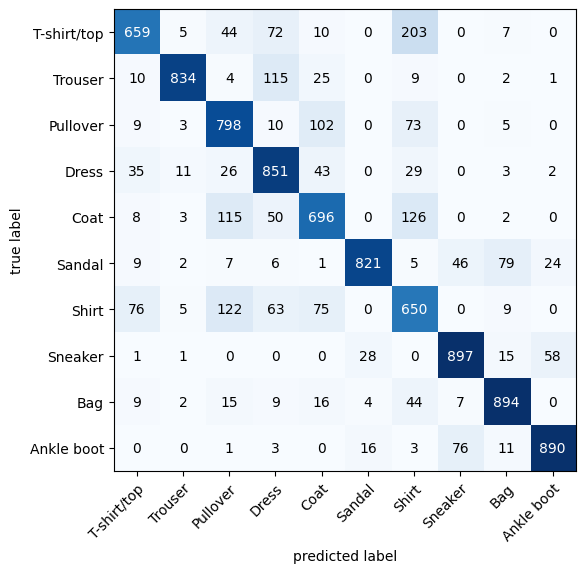

In [80]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# Set up Confusion Matrix Instance and Compare

confmat=ConfusionMatrix(num_classes=len(class_names),task='multiclass')

confmat_tensor=confmat(preds=y_pred_tensor,
                       target=test_data.targets,
                       )


# Plot the Matrix
fig, axis=plot_confusion_matrix(conf_mat=confmat_tensor.numpy(), # CZ matplotlib work  with numpy
                                class_names=class_names,
                                figsize=(6,6)

)

In [63]:
len(test_data.targets)

10000

# Saving and Loading Our Best Model

In [83]:
from pathlib import Path
# Create Model Dic Path
MODEL_PATH=Path("Models")
MODEL_PATH.mkdir(parents=True,
                 exist_ok=True)

# Model Save Path
MODEL_NAME='03_CV_Model_2_CNN.pth'
MODEL_SAVE_PATH=MODEL_PATH/MODEL_NAME

# SAVE MODEL
print("Saving Model")
torch.save(obj=model_2.state_dict(),f=MODEL_SAVE_PATH)
print("SAVED")




Saving Model
SAVED


In [87]:
# Load Model
torch.manual_seed(42)
loaded_model_2=FashionMNISTModelV2(input_shape=1,hidden_unit=10,output_shape=10)
loaded_model_2.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

# Send to Device
loaded_model_2.to(device)

FashionMNISTModelV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [89]:
# Eval Loaded Model
torch.manual_seed(42)
loaded_model_2_results=eval_model(
    loaded_model_2,
    test_dataloader,
    loss_fn,
    accuracy_fn
)

loaded_model_2_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV2',
 'model_losss': 0.31928470730781555,
 'model_acc': 88.6082268370607}

In [93]:
# Check if Model Results are Close to each other

torch.isclose(torch.tensor(model_2_results['model_losss']),
              torch.tensor(loaded_model_2_results['model_losss']),
              atol=1e-02  #absolute tolerence
              )

tensor(True)